In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [2]:
def read_decode_depth(depthpath):
    depth_rgba = cv2.imread(depthpath, cv2.IMREAD_UNCHANGED)
    depth = depth_rgba.view("<f4")
    return np.squeeze(depth, axis=-1)

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pathlib import Path
from PIL import Image

# ─── Load data ───────────────────────────────────────────────────────────────
data_root = Path("/Volumes/T9/datasets")
depth_path = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000" / "depth_lcam_front" / "000000_lcam_front_depth.png"
rgb_path = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000" / "image_lcam_front" / "000000_lcam_front.png"

depth_raw = read_decode_depth(depth_path)  # your existing decoder
img_raw = np.array(Image.open(rgb_path))
depth_m = depth_raw.copy().astype(np.float32)
depth_m[depth_m > 20.0] = np.nan

gray = cv2.cvtColor(img_raw, cv2.COLOR_RGB2GRAY).astype(np.float32)



/var/folders/br/cmzzcsb57_98q6bdzbmph71r0000gn/T/ipykernel_75577/3873420472.py:43: RuntimeWarning: invalid value encountered in divide
  anisotropy_d = np.where(lam1_d > EPS_RATIO, 1.0 - lam2_d / lam1_d, np.nan)


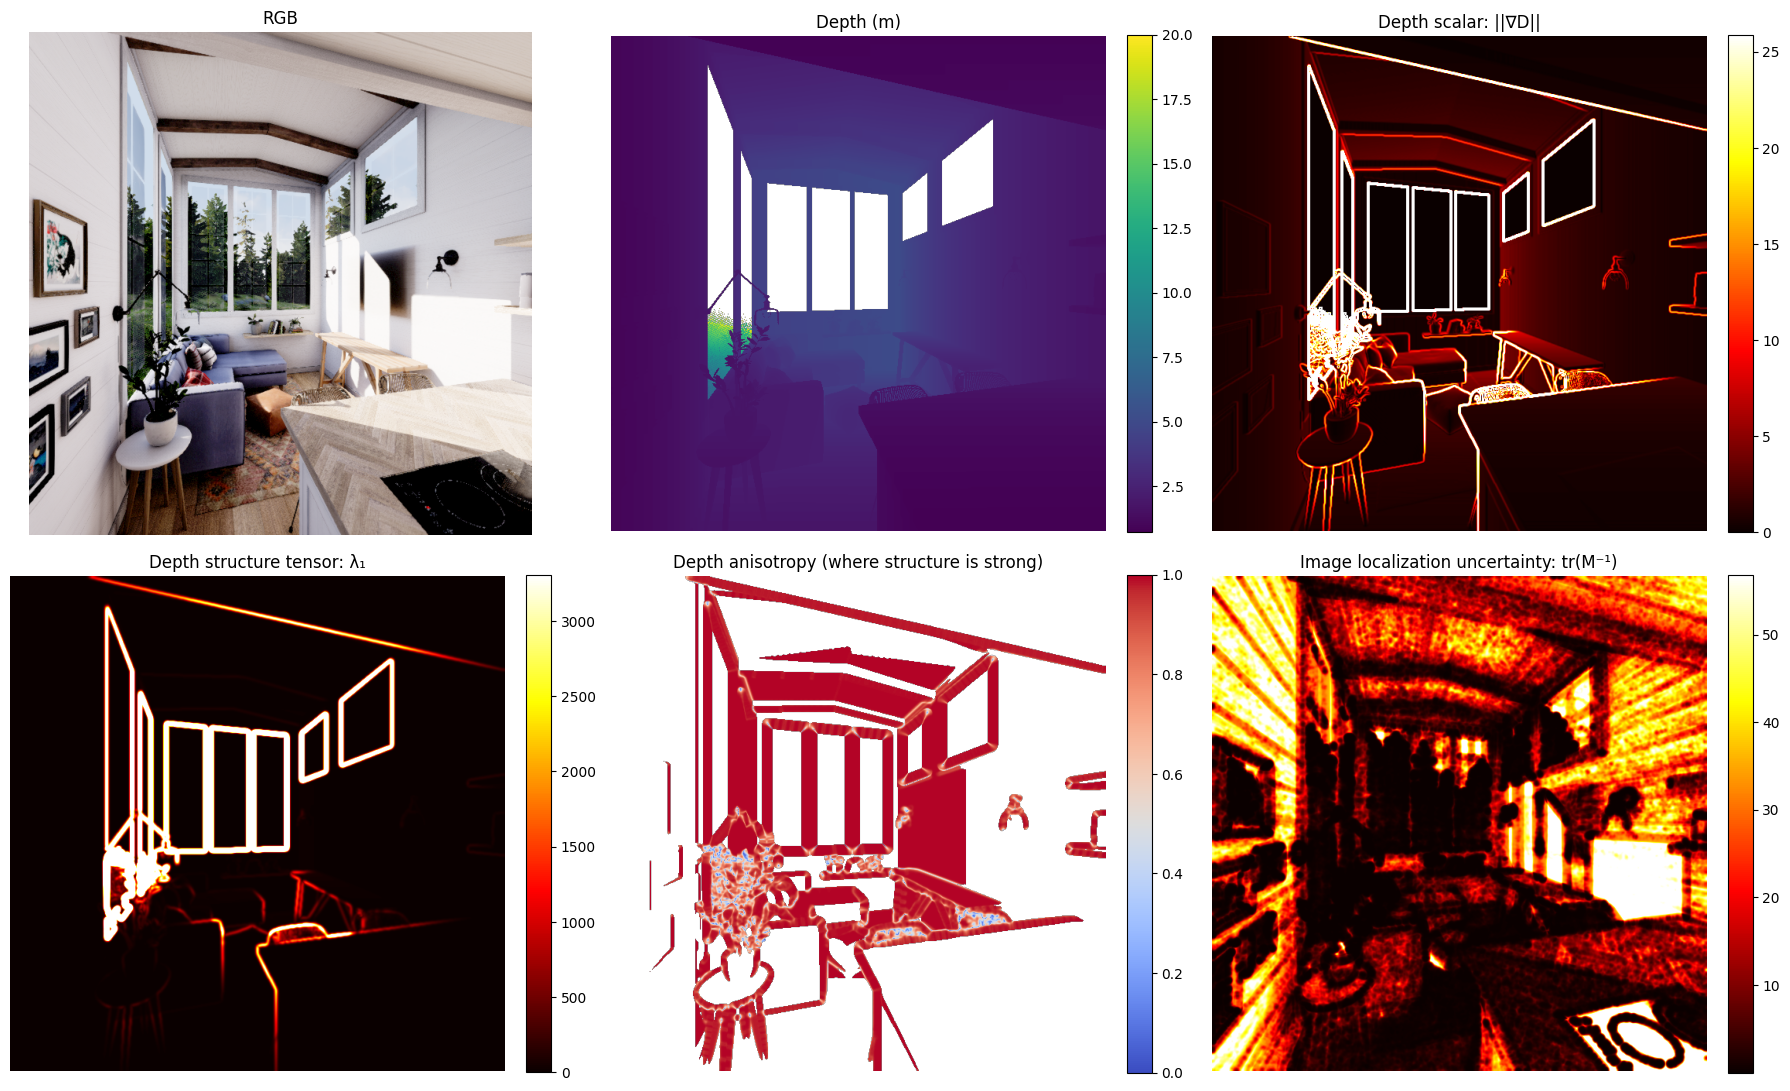

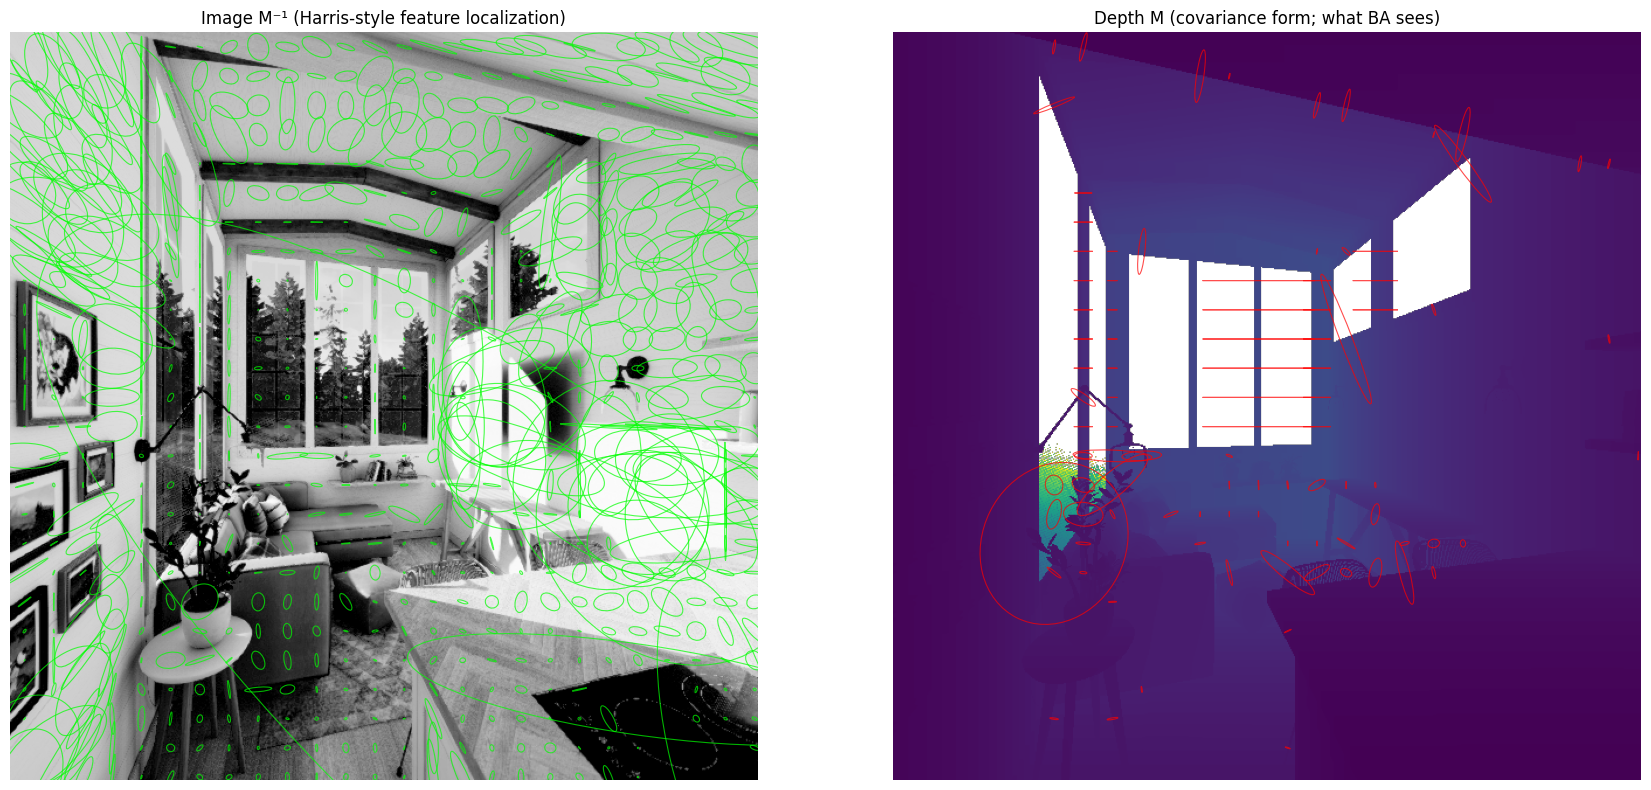

In [7]:
import numpy as np
import cv2
from scipy.ndimage import binary_dilation
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ─── Setup ────────────────────────────────────────────────────────────────
KSIZE_DIFF = 5         # differentiation scale (Sobel kernel)
SIGMA_INTEG = 1.5      # integration scale (Gaussian smoothing of products)
EPS_RATIO = 1e-3       # for safe division in ratios

def structure_tensor(field, ksize_diff=KSIZE_DIFF, sigma_integ=SIGMA_INTEG):
    """Compute structure tensor components with explicit two-scale setup."""
    dx = cv2.Sobel(field, cv2.CV_32F, 1, 0, ksize=ksize_diff)
    dy = cv2.Sobel(field, cv2.CV_32F, 0, 1, ksize=ksize_diff)
    Sxx = cv2.GaussianBlur(dx * dx, (0, 0), sigma_integ)
    Syy = cv2.GaussianBlur(dy * dy, (0, 0), sigma_integ)
    Sxy = cv2.GaussianBlur(dx * dy, (0, 0), sigma_integ)
    return Sxx, Sxy, Syy

def eigenvalues_from_tensor(Sxx, Sxy, Syy):
    """Closed-form 2x2 symmetric eigenvalues. Returns (lam_max, lam_min)."""
    trace = Sxx + Syy
    det = Sxx * Syy - Sxy * Sxy
    discriminant = np.sqrt(np.maximum(trace * trace / 4 - det, 0))
    lam_max = trace / 2 + discriminant
    lam_min = trace / 2 - discriminant
    return lam_max, lam_min

# ─── 1. Depth scalar uncertainty: ||∇D|| ──────────────────────────────────
depth_filled = np.where(np.isnan(depth_m), 0, depth_m)
mask_valid = ~np.isnan(depth_m)

dx_d = cv2.Sobel(depth_filled, cv2.CV_32F, 1, 0, ksize=KSIZE_DIFF)
dy_d = cv2.Sobel(depth_filled, cv2.CV_32F, 0, 1, ksize=KSIZE_DIFF)
grad_mag = np.sqrt(dx_d**2 + dy_d**2)

# ─── 2. Depth structure tensor ─────────────────────────────────────────────
Sxx_d, Sxy_d, Syy_d = structure_tensor(depth_filled)
lam1_d, lam2_d = eigenvalues_from_tensor(Sxx_d, Sxy_d, Syy_d)

# Anisotropy where structure is meaningful
anisotropy_d = np.where(lam1_d > EPS_RATIO, 1.0 - lam2_d / lam1_d, np.nan)

# ─── 3. Image structure tensor (feature-quality only) ──────────────────────
gray_float = gray.astype(np.float32) / 255.0
Sxx_i, Sxy_i, Syy_i = structure_tensor(gray_float)
lam1_i, lam2_i = eigenvalues_from_tensor(Sxx_i, Sxy_i, Syy_i)

# Image localization uncertainty: tr(M^-1), interpreted as inverse-corner-strength
# Use scale-appropriate epsilon based on typical eigenvalue magnitude
eps_img = max(1e-2, 0.01 * np.nanpercentile(lam1_i[lam1_i > 0], 50))
unc_img_scalar = 1.0 / (lam1_i + eps_img) + 1.0 / (lam2_i + eps_img)



# ─── Visualization: scalar maps ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0, 0].imshow(img_raw); axes[0, 0].set_title("RGB")
im1 = axes[0, 1].imshow(depth_m, cmap="viridis"); axes[0, 1].set_title("Depth (m)")
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(grad_mag, cmap="hot",
                         vmax=np.nanpercentile(grad_mag, 95))
axes[0, 2].set_title("Depth scalar: ||∇D||")
fig.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

im3 = axes[1, 0].imshow(lam1_d, cmap="hot",
                         vmax=np.nanpercentile(lam1_d, 95))
axes[1, 0].set_title("Depth structure tensor: λ₁")
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# Mask anisotropy where structure is weak (visualization sanity)
anisotropy_meaningful = np.where(
    lam1_d > np.nanpercentile(lam1_d, 70),
    anisotropy_d,
    np.nan
)
im4 = axes[1, 1].imshow(anisotropy_meaningful, cmap="coolwarm", vmin=0, vmax=1)
axes[1, 1].set_title("Depth anisotropy (where structure is strong)")
fig.colorbar(im4, ax=axes[1, 1], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(unc_img_scalar, cmap="hot",
                         vmax=np.nanpercentile(unc_img_scalar, 95))
axes[1, 2].set_title("Image localization uncertainty: tr(M⁻¹)")
fig.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()


# ─── Visualization: ellipses ───────────────────────────────────────────────
def draw_ellipses(ax, Sxx, Sxy, Syy, mask, mode, step=25, color="lime",
                   global_scale=None, title=""):
    """
    Draw structure tensor ellipses.
    
    mode='inverse':  Draw M^-1 (Harris-style feature localization).
                     Large M eigenvalue → small ellipse → well-localized.
    mode='direct':   Draw M itself (depth fragility as it enters BA).
                     Large M eigenvalue → large ellipse → high variance.
    """
    ax.set_title(title)
    h, w = Sxx.shape
    
    if global_scale is None:
        # Auto: scale ellipses to fit step size on average
        eig_vals_all = []
        for y in range(step // 2, h, step):
            for x in range(step // 2, w, step):
                if not mask[y, x]: continue
                M = np.array([[Sxx[y, x], Sxy[y, x]],
                              [Sxy[y, x], Syy[y, x]]])
                ev = np.linalg.eigvalsh(M)
                eig_vals_all.append(ev)
        eig_vals_all = np.array(eig_vals_all).flatten()
        eig_vals_all = eig_vals_all[eig_vals_all > 1e-6]
        if mode == 'direct':
            global_scale = step / (3 * np.sqrt(np.nanmedian(eig_vals_all)))
        else:  # inverse
            global_scale = step * np.sqrt(np.nanmedian(eig_vals_all)) / 3
    
    for y in range(step // 2, h, step):
        for x in range(step // 2, w, step):
            if not mask[y, x]: continue
            
            M = np.array([[Sxx[y, x], Sxy[y, x]],
                          [Sxy[y, x], Syy[y, x]]])
            eigvals, eigvecs = np.linalg.eigh(M)
            eigvals = np.clip(eigvals, 1e-6, None)
            
            if mode == 'inverse':
                # M^-1 covariance: ellipse axes = sqrt(1/eigval) = 1/sqrt(eigval)
                widths = global_scale / np.sqrt(eigvals)
            elif mode == 'direct':
                # M as covariance: ellipse axes = sqrt(eigval)
                widths = global_scale * np.sqrt(eigvals)
            
            # Eigenvectors: eigh returns ascending order. eigvecs[:, 1] is for larger eigenvalue.
            angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
            ell = Ellipse(xy=(x, y),
                          width=widths[1],
                          height=widths[0],
                          angle=angle, fill=False,
                          edgecolor=color, linewidth=0.8, alpha=0.7)
            ax.add_patch(ell)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(gray, cmap="gray")
draw_ellipses(axes[0], Sxx_i, Sxy_i, Syy_i,
              np.ones_like(gray, dtype=bool),
              mode='inverse', color="lime",
              title="Image M⁻¹ (Harris-style feature localization)")

# For depth, only show top-strength pixels to declutter
depth_strength = lam1_d
strength_threshold = np.nanpercentile(depth_strength[mask_valid], 85)
depth_show_mask = mask_valid & (depth_strength > strength_threshold)

axes[1].imshow(depth_m, cmap="viridis")
draw_ellipses(axes[1], Sxx_d, Sxy_d, Syy_d, depth_show_mask,
              mode='direct', color="red",
              title="Depth M (covariance form; what BA sees)")

for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [48]:
from scipy.ndimage import gaussian_filter, uniform_filter

def depth_uncertainty_source1(depth, sigma_smooth=1.5, sigma_pixel=1.0):
    """
    Gradient term: sigma^2_d = grad^T Sigma_2D grad, isotropic 2D version.
    
    For isotropic 2D noise (sigma_pixel), this reduces to:
        sigma^2_d = (grad_u^2 + grad_v^2) * sigma_pixel^2
    
    Captures along-surface depth change due to 2D detection noise.
    Smooths depth before computing gradient to suppress sensor noise
    and dropout-edge artifacts.
    
    Parameters
    ----------
    depth : (H, W) array, depth in meters, NaN for invalid
    sigma_smooth : float, Gaussian smoothing sigma (pixels) for gradient
    sigma_pixel : float, assumed 2D detection noise std (pixels)
    
    Returns
    -------
    var_d : (H, W) array, depth variance contribution from gradient term (m^2)
    """
    valid = ~np.isnan(depth)
    weight = valid.astype(np.float32)
    
    # NaN-aware Gaussian smoothing: smooth depth*weight and weight separately,
    # then divide. This handles invalid pixels properly.
    depth_filled = np.where(valid, depth, 0.0)
    smoothed_num = gaussian_filter(depth_filled * weight, sigma=sigma_smooth)
    smoothed_den = gaussian_filter(weight, sigma=sigma_smooth)
    
    # Avoid divide-by-zero where the local neighborhood is all invalid
    smoothed = np.where(smoothed_den > 0.1, smoothed_num / np.maximum(smoothed_den, 1e-6), np.nan)
    
    # Centered finite differences for gradient
    grad_v, grad_u = np.gradient(smoothed)
    
    grad_mag_sq = grad_u**2 + grad_v**2
    var_d = grad_mag_sq * (sigma_pixel ** 2)
    
    # Mask result where original pixel was invalid
    var_d = np.where(valid, var_d, np.nan)
    return var_d


def depth_uncertainty_source2(depth, window_size=5):
    """
    Window variance term: Var(d) computed in a local window around each pixel.
    
    Captures depth discontinuities ('hopping' between near and far surfaces).
    NaN-aware: only uses valid pixels in the variance computation.
    
    Parameters
    ----------
    depth : (H, W) array, depth in meters, NaN for invalid
    window_size : int, side length of square window (pixels)
    
    Returns
    -------
    var_d : (H, W) array, depth variance from local window (m^2)
    """
    valid = ~np.isnan(depth)
    weight = valid.astype(np.float32)
    depth_filled = np.where(valid, depth, 0.0)
    
    # Weighted mean and mean-of-squares using uniform filter (box filter)
    # E[d] = sum(d * w) / sum(w)
    # Var[d] = E[d^2] - E[d]^2
    sum_w = uniform_filter(weight, size=window_size) * (window_size ** 2)
    sum_dw = uniform_filter(depth_filled * weight, size=window_size) * (window_size ** 2)
    sum_d2w = uniform_filter(depth_filled**2 * weight, size=window_size) * (window_size ** 2)
    
    # Need at least a few valid samples to compute variance meaningfully
    enough_samples = sum_w >= 4
    
    mean = np.where(enough_samples, sum_dw / np.maximum(sum_w, 1.0), np.nan)
    mean_sq = np.where(enough_samples, sum_d2w / np.maximum(sum_w, 1.0), np.nan)
    var = mean_sq - mean**2
    var = np.maximum(var, 0)  # numerical floor
    var = np.where(valid & enough_samples, var, np.nan)
    return var


def nan_density(depth, window_size=5):
    """
    Fraction of NaN pixels in a local window. Useful for masking
    regions where the formulation is unreliable due to dropout.
    """
    valid = ~np.isnan(depth)
    fill_fraction = uniform_filter(valid.astype(np.float32), size=window_size)
    return 1.0 - fill_fraction

def depth_uncertainty_nan_proximity(depth, window_size=7, sigma_default=0.10):
    """
    NaN proximity term for sensor data with systematic dropout at edges.
    Uses NaN fraction as a discontinuity proxy.
    """
    nan_frac = nan_density(depth, window_size=window_size)
    var_d = (nan_frac ** 2) * (sigma_default ** 2)
    return var_d
    


95th percentile sigma_d: 25.00 cm


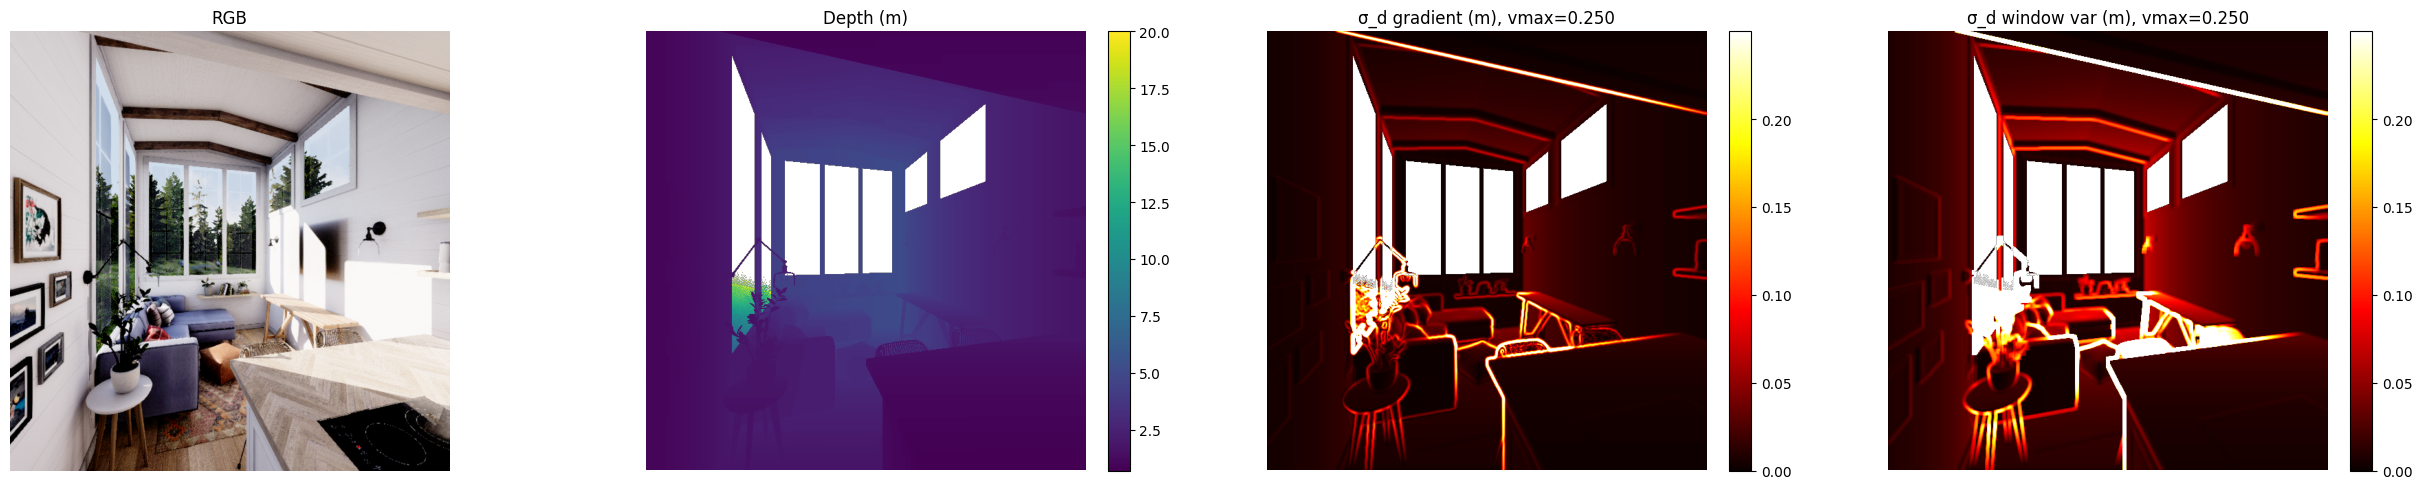

In [49]:
# Compute the maps
var_grad = depth_uncertainty_source1(depth_m, sigma_smooth=1.5, sigma_pixel=1.0)
var_window = depth_uncertainty_source2(depth_m, window_size=7)
var_nan_prox = depth_uncertainty_nan_proximity(depth_m, window_size=7)
var_total = np.where(
    np.isnan(var_grad) | np.isnan(var_window),
    np.nan,
    var_grad + var_window
)
nan_frac = nan_density(depth_m, window_size=5)

sigma_grad = np.sqrt(var_grad)
sigma_window = np.sqrt(var_window)
sigma_total = np.sqrt(var_total)
sigma_prox = np.sqrt(var_nan_prox)

# Pick a vmax for the uncertainty heatmaps based on the data
# 95th percentile is a reasonable cap; tune if needed
vmax = np.nanpercentile(sigma_total, 95)
print(f"95th percentile sigma_d: {vmax*100:.2f} cm")

# Five-panel visualization
fig, axes = plt.subplots(1, 4, figsize=(25, 5))

axes[0].imshow(img_raw)
axes[0].set_title("RGB")
axes[0].axis("off")

im1 = axes[1].imshow(depth_m, cmap="viridis")
axes[1].set_title("Depth (m)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(sigma_grad, cmap="hot", vmin=0, vmax=vmax)
axes[2].set_title(f"σ_d gradient (m), vmax={vmax:.3f}")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(sigma_window, cmap="hot", vmin=0, vmax=vmax)
axes[3].set_title(f"σ_d window var (m), vmax={vmax:.3f}")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# im4 = axes[4].imshow(sigma_prox, cmap="gray_r", vmin=0, vmax=vmax)
# axes[4].set_title("var nan prox")
# axes[4].axis("off")
# plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

DIAGNOSTIC: depth weighting on 5 TartanAir frames


──── Frame 0 ────────────────────────────────────────────────────
Keypoints: 1500 total, 524 on NaN depth (34.9%)
Keypoint fragility distribution vs all pixels:
  All pixels:  median=0.85, P90=12.68, max=545602.9
  Keypoints:   median=18.29, P90=5882.46, max=472595.5
  Fraction of keypoints in top-10% fragile pixels: 0.538
  (Uniform would be 0.10, edge-biased >> 0.10)

  Per-λ weight statistics (after mean-1 normalization):
         λ |   raw_mean |    std |    P10 |    P90 | frac<0.5 | frac<0.1
  -------- | ---------- | ------ | ------ | ------ | -------- | --------
     1e-05 |     0.9658 |  0.118 |  0.978 |  1.035 |    0.019 |    0.000
     1e-04 |     0.8997 |  0.253 |  0.700 |  1.111 |    0.074 |    0.020
     1e-03 |     0.7876 |  0.419 |  0.185 |  1.269 |    0.177 |    0.074
     1e-02 |     0.6323 |  0.623 |  0.026 |  1.572 |    0.295 |    0.178
     1e-01 |     0.4312 |  0.896 |  0.004 |  2.190 |    0.439 |    0.292
     1e+

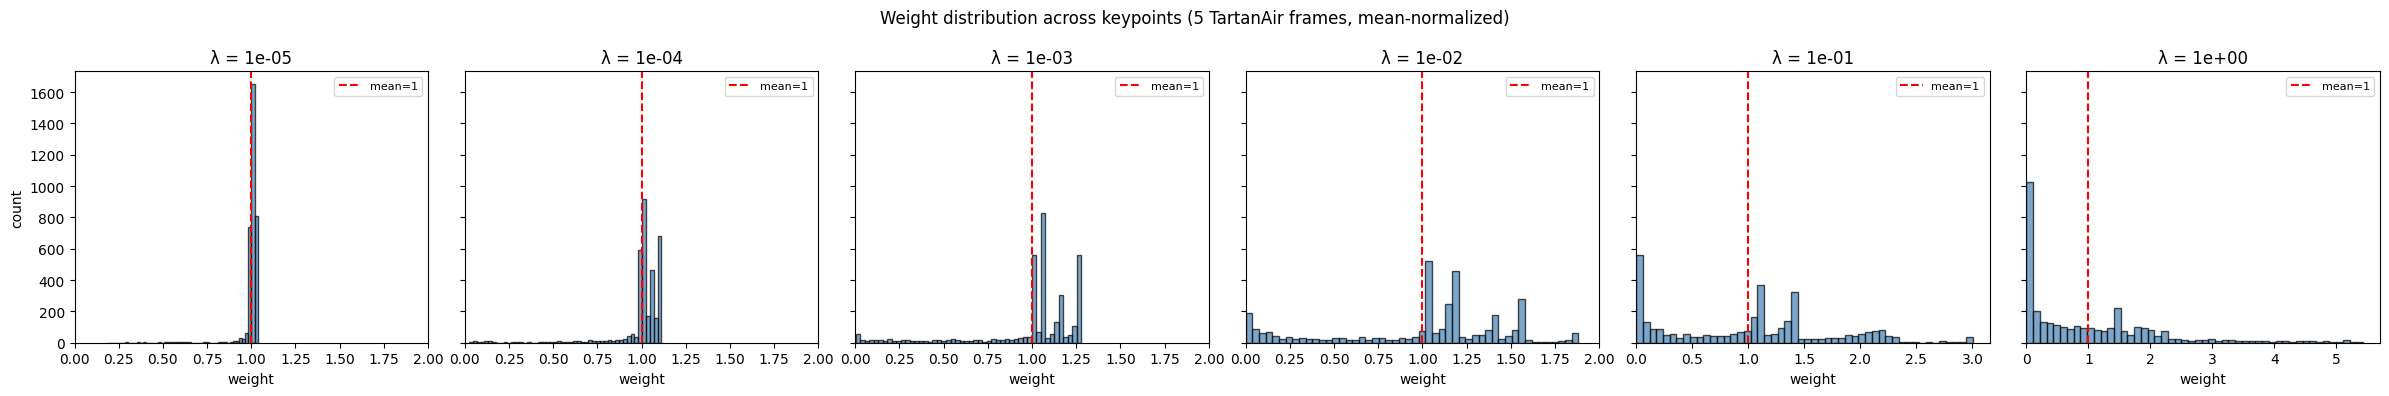



λ RANGE RECOMMENDATION

Looking for λ where:
  - Mean raw weight in [0.3, 0.8] (meaningful relative downweighting)
  - Std of normalized weights > 0.1 (real variation across keypoints)
  - Frac<0.5 in [0.1, 0.4] (some keypoints suppressed, not all)

  λ=1e-02: useful regime ✓ (mean_raw=0.734, std=0.464, frac<0.5=0.202)
  λ=1e-01: useful regime ✓ (mean_raw=0.557, std=0.721, frac<0.5=0.333)

Sweep these λ values for the main experiment: [0.01, 0.1]
Plus 1 below and 1 above for safety margin.


In [52]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# ─── Reuse helpers ──────────────────────────────────────────────────────────
KSIZE_DIFF = 5
SIGMA_INTEG = 1.5

def read_decode_depth(depthpath):
    depth_rgba = cv2.imread(str(depthpath), cv2.IMREAD_UNCHANGED)
    if depth_rgba is None:
        raise FileNotFoundError(f"Could not read depth file: {depthpath}")
    depth = depth_rgba.view("<f4")
    return np.squeeze(depth, axis=-1)

def compute_grad_mag_sq(depth_m):
    """Compute ||∇D||² with proper NaN handling for any depth map."""
    mask_valid = ~np.isnan(depth_m)
    depth_filled = np.where(mask_valid, depth_m, 0).astype(np.float32)
    
    dx = cv2.Sobel(depth_filled, cv2.CV_32F, 1, 0, ksize=KSIZE_DIFF)
    dy = cv2.Sobel(depth_filled, cv2.CV_32F, 0, 1, ksize=KSIZE_DIFF)
    grad_mag_sq = dx * dx + dy * dy
    
    # Dilate NaN mask to handle gradient contamination at boundaries
    from scipy.ndimage import binary_dilation
    nan_mask = ~mask_valid
    contam_radius = KSIZE_DIFF // 2 + 1
    contaminated = binary_dilation(nan_mask, iterations=contam_radius)
    grad_mag_sq[contaminated] = np.nan
    
    return grad_mag_sq


def compute_depth_weight(kp_uv, grad_mag_sq, lambda_d):
    """
    Per-keypoint depth weight, normalized so mean=1 over valid keypoints.
    
    Args:
        kp_uv: (N, 2) array of (u, v) pixel coords (OpenCV convention)
        grad_mag_sq: (H, W) fragility map (||∇D||²), may have NaN
        lambda_d: weighting strength
    
    Returns:
        weights: (N,) array, mean = 1 over valid keypoints
        nan_mask: (N,) bool array, True where keypoint has invalid depth
    """
    H, W = grad_mag_sq.shape
    u = np.clip(kp_uv[:, 0].astype(int), 0, W - 1)
    v = np.clip(kp_uv[:, 1].astype(int), 0, H - 1)
    
    fragility = grad_mag_sq[v, u]
    nan_mask = np.isnan(fragility)
    fragility_safe = np.where(nan_mask, 0, fragility)
    
    raw_weights = 1.0 / (1.0 + lambda_d * fragility_safe)
    
    valid = ~nan_mask
    if valid.sum() > 0:
        mean_w = raw_weights[valid].mean()
        if mean_w > 1e-9:
            raw_weights = raw_weights / mean_w
    
    # NaN-depth keypoints fall back to weight 1 (no effect)
    raw_weights[nan_mask] = 1.0
    
    return raw_weights, nan_mask


# ─── Test on 5 TartanAir frames ─────────────────────────────────────────────
data_root = Path("/Volumes/T9/datasets")
sequence_dir = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000"
depth_dir = sequence_dir / "depth_lcam_front"
rgb_dir = sequence_dir / "image_lcam_front"

# Pick 5 frames spread across the sequence
all_depth_files = sorted([
    f for f in depth_dir.glob("*_lcam_front_depth.png")
    if not f.name.startswith(".")
])
n_total = len(all_depth_files)
frame_indices = np.linspace(0, n_total - 1, 5, dtype=int)

# ORB detector matching pySLAM's typical config
orb = cv2.ORB_create(nfeatures=1500, scaleFactor=1.2, nlevels=8)

# λ values to test
lambda_values = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

print(f"{'='*100}")
print(f"DIAGNOSTIC: depth weighting on {len(frame_indices)} TartanAir frames")
print(f"{'='*100}\n")

# Storage for cross-frame summary
summary = {lam: {'mean_raw': [], 'std_norm': [], 'p10_norm': [], 'p90_norm': [], 
                  'frac_lt_0_5': [], 'frac_lt_0_1': []} for lam in lambda_values}

for frame_idx in frame_indices:
    depth_path = all_depth_files[frame_idx]
    rgb_name = depth_path.name.replace("_depth.png", ".png")
    rgb_path = rgb_dir / rgb_name
    
    # Load
    depth_raw = read_decode_depth(depth_path)
    img_raw = np.array(Image.open(rgb_path))
    depth_m = depth_raw.copy().astype(np.float32)
    depth_m[depth_m > 20.0] = np.nan
    gray = cv2.cvtColor(img_raw, cv2.COLOR_RGB2GRAY)
    
    # Compute fragility map
    grad_mag_sq = compute_grad_mag_sq(depth_m)
    
    # Detect ORB keypoints
    keypoints = orb.detect(gray, None)
    if len(keypoints) == 0:
        print(f"Frame {frame_idx}: no keypoints detected, skipping")
        continue
    
    kp_uv = np.array([kp.pt for kp in keypoints])  # (N, 2) in (u, v)
    n_kp = len(keypoints)
    
    # Sample fragility at keypoints (raw, for distribution comparison)
    u_int = np.clip(kp_uv[:, 0].astype(int), 0, grad_mag_sq.shape[1] - 1)
    v_int = np.clip(kp_uv[:, 1].astype(int), 0, grad_mag_sq.shape[0] - 1)
    kp_fragility = grad_mag_sq[v_int, u_int]
    n_nan_kp = np.isnan(kp_fragility).sum()
    
    # Compare keypoint fragility distribution vs all-pixel fragility distribution
    all_pixel_frag = grad_mag_sq[~np.isnan(grad_mag_sq)].flatten()
    kp_frag_valid = kp_fragility[~np.isnan(kp_fragility)]
    
    pct_threshold = np.percentile(all_pixel_frag, 90)
    frac_kp_in_top10 = (kp_frag_valid > pct_threshold).mean()
    
    print(f"\n──── Frame {frame_idx} ────────────────────────────────────────────────────")
    print(f"Keypoints: {n_kp} total, {n_nan_kp} on NaN depth ({100*n_nan_kp/n_kp:.1f}%)")
    print(f"Keypoint fragility distribution vs all pixels:")
    print(f"  All pixels:  median={np.median(all_pixel_frag):.2f}, "
          f"P90={pct_threshold:.2f}, max={all_pixel_frag.max():.1f}")
    print(f"  Keypoints:   median={np.median(kp_frag_valid):.2f}, "
          f"P90={np.percentile(kp_frag_valid, 90):.2f}, max={kp_frag_valid.max():.1f}")
    print(f"  Fraction of keypoints in top-10% fragile pixels: {frac_kp_in_top10:.3f}")
    print(f"  (Uniform would be 0.10, edge-biased >> 0.10)")
    
    print(f"\n  Per-λ weight statistics (after mean-1 normalization):")
    print(f"  {'λ':>8s} | {'raw_mean':>10s} | {'std':>6s} | {'P10':>6s} | {'P90':>6s} | "
          f"{'frac<0.5':>8s} | {'frac<0.1':>8s}")
    print(f"  {'-'*8} | {'-'*10} | {'-'*6} | {'-'*6} | {'-'*6} | {'-'*8} | {'-'*8}")
    
    for lam in lambda_values:
        weights, nan_kp = compute_depth_weight(kp_uv, grad_mag_sq, lam)
        weights_valid = weights[~nan_kp]
        
        # Raw mean before normalization (for reference)
        raw_w = 1.0 / (1.0 + lam * kp_frag_valid)
        mean_raw = raw_w.mean()
        
        std_w = weights_valid.std()
        p10 = np.percentile(weights_valid, 10)
        p90 = np.percentile(weights_valid, 90)
        frac_lt_05 = (weights_valid < 0.5).mean()
        frac_lt_01 = (weights_valid < 0.1).mean()
        
        print(f"  {lam:>8.0e} | {mean_raw:>10.4f} | {std_w:>6.3f} | "
              f"{p10:>6.3f} | {p90:>6.3f} | {frac_lt_05:>8.3f} | {frac_lt_01:>8.3f}")
        
        summary[lam]['mean_raw'].append(mean_raw)
        summary[lam]['std_norm'].append(std_w)
        summary[lam]['p10_norm'].append(p10)
        summary[lam]['p90_norm'].append(p90)
        summary[lam]['frac_lt_0_5'].append(frac_lt_05)
        summary[lam]['frac_lt_0_1'].append(frac_lt_01)


# ─── Cross-frame summary ────────────────────────────────────────────────────
print(f"\n\n{'='*100}")
print(f"CROSS-FRAME SUMMARY (averaged across {len(frame_indices)} frames)")
print(f"{'='*100}\n")
print(f"{'λ':>8s} | {'raw_mean':>10s} | {'std':>6s} | {'P10':>6s} | {'P90':>6s} | "
      f"{'frac<0.5':>8s} | {'frac<0.1':>8s}")
print(f"{'-'*8} | {'-'*10} | {'-'*6} | {'-'*6} | {'-'*6} | {'-'*8} | {'-'*8}")
for lam in lambda_values:
    s = summary[lam]
    print(f"{lam:>8.0e} | {np.mean(s['mean_raw']):>10.4f} | {np.mean(s['std_norm']):>6.3f} | "
          f"{np.mean(s['p10_norm']):>6.3f} | {np.mean(s['p90_norm']):>6.3f} | "
          f"{np.mean(s['frac_lt_0_5']):>8.3f} | {np.mean(s['frac_lt_0_1']):>8.3f}")


# ─── Visualize: weight distribution histograms ──────────────────────────────
fig, axes = plt.subplots(1, len(lambda_values), figsize=(4 * len(lambda_values), 4), 
                          sharey=True)

# Collect all keypoint weights across all frames for each lambda
all_weights = {lam: [] for lam in lambda_values}
for frame_idx in frame_indices:
    depth_path = all_depth_files[frame_idx]
    rgb_name = depth_path.name.replace("_depth.png", ".png")
    rgb_path = rgb_dir / rgb_name
    
    depth_raw = read_decode_depth(depth_path)
    img_raw = np.array(Image.open(rgb_path))
    depth_m = depth_raw.copy().astype(np.float32)
    depth_m[depth_m > 20.0] = np.nan
    gray = cv2.cvtColor(img_raw, cv2.COLOR_RGB2GRAY)
    
    grad_mag_sq = compute_grad_mag_sq(depth_m)
    keypoints = orb.detect(gray, None)
    if len(keypoints) == 0:
        continue
    kp_uv = np.array([kp.pt for kp in keypoints])
    
    for lam in lambda_values:
        weights, nan_kp = compute_depth_weight(kp_uv, grad_mag_sq, lam)
        all_weights[lam].extend(weights[~nan_kp].tolist())

for ax, lam in zip(axes, lambda_values):
    weights = np.array(all_weights[lam])
    ax.hist(weights, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(1.0, color='red', linestyle='--', label='mean=1')
    ax.set_title(f'λ = {lam:.0e}')
    ax.set_xlabel('weight')
    ax.set_xlim(0, max(2.0, weights.max() * 1.05))
    if lam == lambda_values[0]:
        ax.set_ylabel('count')
    ax.legend(fontsize=8)
    
plt.suptitle('Weight distribution across keypoints (5 TartanAir frames, mean-normalized)')
plt.tight_layout()
plt.show()


# ─── Recommend λ range ───────────────────────────────────────────────────────
print(f"\n\n{'='*100}")
print(f"λ RANGE RECOMMENDATION")
print(f"{'='*100}\n")
print("Looking for λ where:")
print("  - Mean raw weight in [0.3, 0.8] (meaningful relative downweighting)")
print("  - Std of normalized weights > 0.1 (real variation across keypoints)")
print("  - Frac<0.5 in [0.1, 0.4] (some keypoints suppressed, not all)\n")

useful_lambdas = []
for lam in lambda_values:
    mean_raw = np.mean(summary[lam]['mean_raw'])
    std_norm = np.mean(summary[lam]['std_norm'])
    frac_05 = np.mean(summary[lam]['frac_lt_0_5'])
    if 0.3 <= mean_raw <= 0.8 and std_norm > 0.1 and 0.1 <= frac_05 <= 0.4:
        useful_lambdas.append(lam)
        print(f"  λ={lam:.0e}: useful regime ✓ "
              f"(mean_raw={mean_raw:.3f}, std={std_norm:.3f}, frac<0.5={frac_05:.3f})")

if useful_lambdas:
    print(f"\nSweep these λ values for the main experiment: {useful_lambdas}")
    print(f"Plus 1 below and 1 above for safety margin.")
else:
    print("\nNo λ in the tested range hit the 'useful regime' criteria.")
    print("Either widen the search, refine criteria, or accept that the chosen λ values")
    print("either underweight (too small) or overweight (too large) on this data.")